# 6. Gradient boosting: XGBoost and LightGBM

**Question: how do shrinkage, tree count and explicit L1/L2 penalties trade against each
other on a rare-event problem?**

Boosting exposes regularization the most directly of any family here. Learning rate and
number of rounds trade off almost exactly — halve the rate, double the rounds — while
`reg_alpha` and `reg_lambda` penalise leaf weights the way L1 and L2 penalise
coefficients in [notebook 03](03_logistic_regularization.ipynb).

The two libraries differ in how they grow trees: XGBoost grows level-wise, LightGBM
leaf-wise. Leaf-wise growth chases the largest loss reduction, which on imbalanced data
can mean chasing the rare class harder — sometimes helpfully, sometimes into
overfitting.

Both also expose `scale_pos_weight`, an imbalance lever examined properly in
[notebook 08](08_imbalance_methods.ipynb).

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.costs import optimize_score_threshold
from scania_aps.metrics import evaluate_scores
from scania_aps.model_search import candidates_for_family
from scania_aps.models.factory import build_candidate
from scania_aps.scoring import positive_class_scores
from scania_aps.split import development_split

split = development_split(train.X, train.y)

rows = []
for family in ("xgboost", "lightgbm"):
    for candidate in candidates_for_family(family, profile="full"):
        model = build_candidate(candidate)
        model.fit(split.X_fit, split.y_fit)
        scores = positive_class_scores(model, split.X_tune)
        chosen = optimize_score_threshold(split.y_tune.to_numpy(), scores.values)
        evaluation = evaluate_scores(
            split.y_tune.to_numpy(),
            scores.values,
            chosen.threshold,
            score_kind=scores.kind,
        )
        rows.append(
            {
                "family": family,
                "name": candidate.name,
                **{
                    k: v
                    for k, v in candidate.parameters.items()
                    if k
                    in {
                        "learning_rate",
                        "n_estimators",
                        "max_depth",
                        "num_leaves",
                        "reg_alpha",
                        "reg_lambda",
                        "subsample",
                        "positive_class_weight",
                    }
                },
                "tune_cost": evaluation.total_cost,
                "false_negatives": evaluation.false_negatives,
                "pr_auc": evaluation.pr_auc,
            }
        )

boosting = pd.DataFrame(rows).sort_values("tune_cost")
boosting.head(20)

,family,name,n_estimators,learning_rate,max_depth,subsample,reg_alpha,reg_lambda,tune_cost,false_negatives,pr_auc,num_leaves,positive_class_weight
13,lightgbm,lightgbm_1,850,0.025000,NaN,0.750000,0.500000,5.000000,3860.0,3,0.895643,63.0,20.0
22,lightgbm,lightgbm_10,745,0.017183,NaN,0.925424,0.205850,6.258654,4040.0,4,0.882735,15.0,1.0
16,lightgbm,lightgbm_4,802,0.014147,NaN,0.779779,0.106048,7.819863,4060.0,4,0.888393,127.0,10.0
17,lightgbm,lightgbm_5,681,0.018503,NaN,0.672336,0.092933,5.551146,4150.0,4,0.888441,31.0,20.0
19,lightgbm,lightgbm_7,682,0.063581,NaN,0.988628,0.005505,1.203544,4280.0,4,0.892600,15.0,20.0
12,lightgbm,lightgbm_0,600,0.040000,NaN,0.850000,0.000000,1.000000,4310.0,5,0.895083,31.0,20.0
11,xgboost,xgboost_11,688,0.046654,5.0,0.690086,0.016356,1.998137,4370.0,4,0.891384,NaN,NaN
15,lightgbm,lightgbm_3,362,0.032822,NaN,0.894079,3.840786,5.641639,4420.0,6,0.886326,127.0,50.0
21,lightgbm,lightgbm_9,740,0.023301,NaN,0.931668,0.002264,3.719141,4420.0,5,0.893609,63.0,50.0
0,xgboost,xgboost_0,500,0.050000,5.0,0.850000,0.000000,1.000000,4490.0,4,0.891030,NaN,NaN


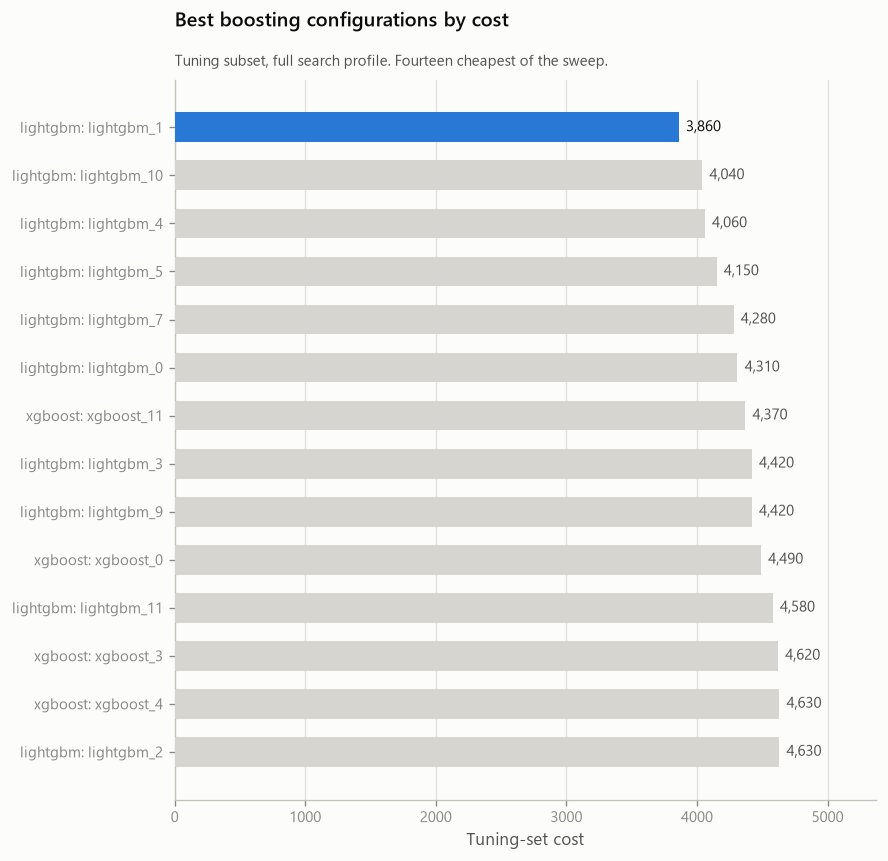

In [3]:
from scania_aps.plotting import emphasis_bars

top = boosting.head(14)
fig, ax = emphasis_bars(
    [f"{r.family}: {r.name}" for r in top.itertuples()],
    [float(v) for v in top["tune_cost"].to_numpy()],
    title="Best boosting configurations by cost",
    subtitle="Tuning subset, full search profile. Fourteen cheapest of the sweep.",
    xlabel="Tuning-set cost",
)

## Learning rate against cost

Shrinkage is the single most important boosting hyperparameter. Plotting cost against it,
separately per library, shows whether the two agree on where the sweet spot is.

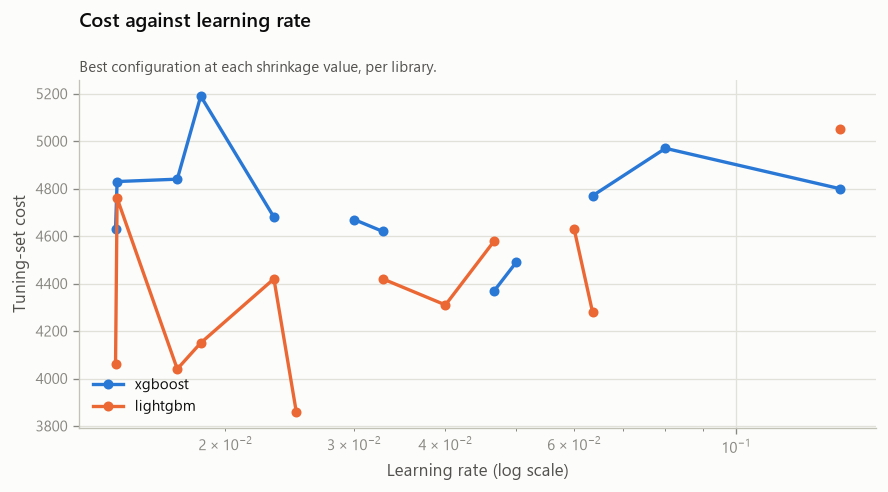

In [4]:
from scania_aps.plotting import series_lines

series = {}
rates = sorted(boosting["learning_rate"].dropna().unique())
for family in ("xgboost", "lightgbm"):
    subset = boosting[boosting["family"] == family]
    if subset.empty:
        continue
    by_rate = subset.groupby("learning_rate")["tune_cost"].min()
    series[family] = np.array([by_rate.get(r, np.nan) for r in rates], dtype=float)

if series and len(rates) > 1:
    fig, ax = series_lines(
        np.array(rates, dtype=float),
        series,
        title="Cost against learning rate",
        subtitle="Best configuration at each shrinkage value, per library.",
        xlabel="Learning rate (log scale)",
        ylabel="Tuning-set cost",
        log_x=True,
        mark_minimum=True,
    )
else:
    print("Not enough distinct learning rates in the sweep to plot a curve.")

### Reading the result

Two things to look for. First, whether the libraries land on the same learning rate — if
they do, the shrinkage optimum is a property of the data, not of the implementation.
Second, how flat the curve is around its minimum: a flat basin means the choice is not
critical and the search can be spent elsewhere.

**Next:** [07 — neural network optimization](07_neural_network_optimization.ipynb), the
only family where the optimiser itself is a free choice.